# TinyML Payload Fall Detection
**Workflow:** phyphox Gyroscope X/Y → continuous signals → windows → mean/std/RMS → 6 features → SAFE/FALL → Binary MLP → Keras → TFLite → INT8 → TFLite inference → verification → `.h`.


In [ ]:
# CELL 1 — IMPORTS
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
# CELL 2 — UPLOAD PHYPhOX CSV
uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("File:", filename)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Saving Raw Data.csv to Raw Data.csv
File: Raw Data.csv
Shape: (5938, 5)
Columns: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']


,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
0,0.089246,0.058987,-0.045650,-0.020075,0.077243
1,0.091742,0.063250,-0.041387,-0.017875,0.077672
2,0.094237,0.065450,-0.034925,-0.010450,0.074918
3,0.096733,0.064350,-0.028600,-0.007287,0.070795
4,0.099228,0.064350,-0.027500,-0.007287,0.070358


In [ ]:
# CELL 3 — RAW DATA CHECK
print("Missing values:")
display(df.isnull().sum())

print("\nData types:")
display(df.dtypes)

print("\nSummary:")
display(df.describe())

Missing values:


,0
Time (s),0
Gyroscope x (rad/s),0
Gyroscope y (rad/s),0
Gyroscope z (rad/s),0
Absolute (rad/s),0



Data types:


,0
Time (s),float64
Gyroscope x (rad/s),float64
Gyroscope y (rad/s),float64
Gyroscope z (rad/s),float64
Absolute (rad/s),float64



Summary:


,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
count,5938.000000,5938.000000,5938.000000,5938.000000,5938.000000
mean,7.496774,0.051855,0.000865,-0.015195,0.502783
std,4.277806,0.594140,0.497153,0.235861,0.637088
min,0.089246,-1.818987,-2.490400,-0.883987,0.003248
25%,3.793025,-0.093363,-0.123475,-0.081813,0.085329
50%,7.496783,0.008938,-0.006187,-0.007287,0.252471
75%,11.200529,0.170913,0.083187,0.036438,0.667154
max,14.904266,4.289175,3.982137,1.656737,4.565783


In [ ]:
# ============================================================
# CELL 4 — Detect the correct sensor columns
# ============================================================

# IMPORTANT:
# Reload the CSV so that we are working directly with the
# original uploaded file and not an old/modified dataframe.

CSV_FILE = "Raw Data.csv"

df = pd.read_csv(CSV_FILE)

print("CSV columns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

# Exact column names from the uploaded CSV
time_col = "Time (s)"
x_col = "Gyroscope x (rad/s)"
y_col = "Gyroscope y (rad/s)"

# Verify that the columns actually exist
required_columns = [time_col, x_col, y_col]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(
            f"Column '{col}' was not found in the CSV.\n"
            f"Available columns: {list(df.columns)}"
        )

print("\nDetected columns:")
print("Time:", time_col)
print("X:", x_col)
print("Y:", y_col)

# Make absolutely sure X and Y are different columns
if x_col == y_col:
    raise ValueError("ERROR: X and Y column names are identical!")

print("\n✓ Correct X and Y columns detected.")

CSV columns:
0 : Time (s)
1 : Gyroscope x (rad/s)
2 : Gyroscope y (rad/s)
3 : Gyroscope z (rad/s)
4 : Absolute (rad/s)

Detected columns:
Time: Time (s)
X: Gyroscope x (rad/s)
Y: Gyroscope y (rad/s)

✓ Correct X and Y columns detected.


In [ ]:
# ============================================================
# CELL 5 — Prepare the correct X and Y sensor data
# ============================================================

data = pd.DataFrame({
    "time": pd.to_numeric(df[time_col], errors="coerce"),
    "x": pd.to_numeric(df[x_col], errors="coerce"),
    "y": pd.to_numeric(df[y_col], errors="coerce")
})

# Remove missing values
data = data.dropna().reset_index(drop=True)

# Sort according to time
data = data.sort_values("time").reset_index(drop=True)

print("Prepared data shape:", data.shape)

print("\nFirst 5 rows:")
display(data.head())

print("\nFirst X values:")
print(data["x"].head().to_numpy())

print("\nFirst Y values:")
print(data["y"].head().to_numpy())

# Check whether X and Y are actually different
difference = np.abs(data["x"].values - data["y"].values)

print("\nMaximum absolute difference between X and Y:",
      difference.max())

print("Are X and Y identical?",
      np.array_equal(data["x"].values, data["y"].values))

if np.array_equal(data["x"].values, data["y"].values):
    raise ValueError(
        "ERROR: X and Y are identical. Check the CSV loading."
    )

print("\n✓ SUCCESS: X and Y are different and correctly loaded.")

Prepared data shape: (5938, 3)

First 5 rows:


,time,x,y
0,0.089246,0.058987,-0.045650
1,0.091742,0.063250,-0.041387
2,0.094237,0.065450,-0.034925
3,0.096733,0.064350,-0.028600
4,0.099228,0.064350,-0.027500



First X values:
[0.0589875 0.06325   0.06545   0.06435   0.06435  ]

First Y values:
[-0.04565   -0.0413875 -0.034925  -0.0286    -0.0275   ]

Maximum absolute difference between X and Y: 3.4612873794
Are X and Y identical? False

✓ SUCCESS: X and Y are different and correctly loaded.


In [ ]:
# CELL 6 — SAMPLING RATE
dt = data["time"].diff().dropna().median()
if dt <= 0:
    raise ValueError("Invalid Time column.")

sampling_rate = 1.0 / dt
duration = data["time"].iloc[-1] - data["time"].iloc[0]

print(f"Sampling rate: {sampling_rate:.2f} Hz")
print(f"Duration: {duration:.2f} s")
print(f"Samples: {len(data)}")

Sampling rate: 400.74 Hz
Duration: 14.82 s
Samples: 5938


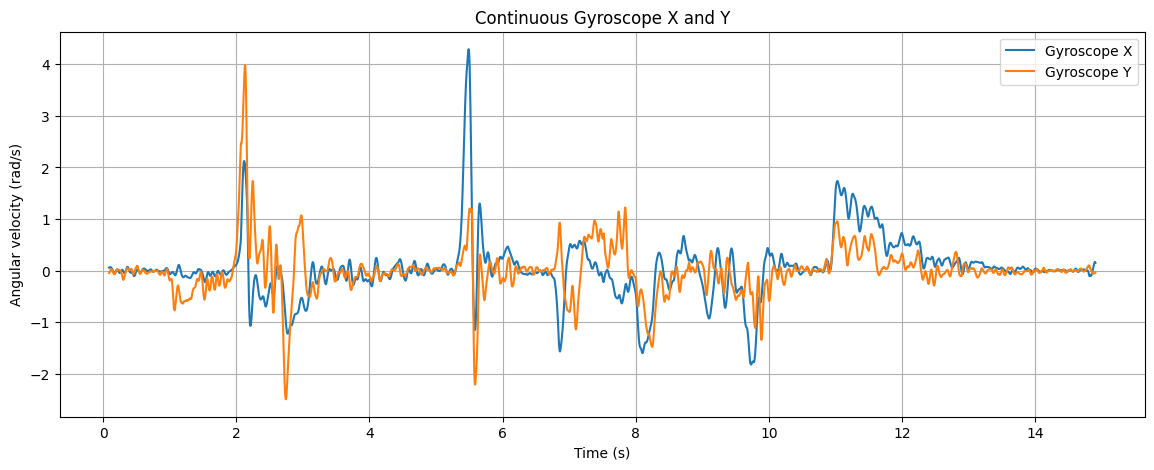

In [ ]:
# CELL 7 — RAW X/Y SIGNALS
plt.figure(figsize=(14,5))
plt.plot(data["time"], data["x"], label="Gyroscope X")
plt.plot(data["time"], data["y"], label="Gyroscope Y")
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.title("Continuous Gyroscope X and Y")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# CELL 8 — WINDOWING
WINDOW_SECONDS = 1.0
OVERLAP = 0.50

window_size = int(round(sampling_rate * WINDOW_SECONDS))
step_size = int(round(window_size * (1 - OVERLAP)))

print("Window:", WINDOW_SECONDS, "s")
print("Samples/window:", window_size)
print("Overlap:", OVERLAP * 100, "%")
print("Step:", step_size, "samples")

Window: 1.0 s
Samples/window: 401
Overlap: 50.0 %
Step: 200 samples


In [ ]:
# CELL 9 — CREATE WINDOWS + SET ACTUAL SLIP TIME
windows = []
start = 0
window_number = 0

while start + window_size <= len(data):
    w = data.iloc[start:start + window_size].copy()
    windows.append({
        "window_number": window_number,
        "data": w,
        "start_time": w["time"].iloc[0],
        "end_time": w["time"].iloc[-1],
        "center_time": (w["time"].iloc[0] + w["time"].iloc[-1]) / 2
    })
    start += step_size
    window_number += 1

print("Windows created:", len(windows))
print(f"Window centers: {windows[0]['center_time']:.2f} to {windows[-1]['center_time']:.2f} s")

# CHANGE THIS to the ACTUAL physical slip/fall time.
SLIP_TIME = 9.6

print("Current SLIP_TIME:", SLIP_TIME, "s")

Windows created: 28
Window centers: 0.59 to 14.06 s
Current SLIP_TIME: 9.6 s


In [ ]:
# CELL 10 — SIX FEATURES
def extract_features(w):
    x = w["x"].to_numpy(dtype=np.float32)
    y = w["y"].to_numpy(dtype=np.float32)
    return {
        "x_mean": np.mean(x),
        "x_std": np.std(x),
        "x_rms": np.sqrt(np.mean(x**2)),
        "y_mean": np.mean(y),
        "y_std": np.std(y),
        "y_rms": np.sqrt(np.mean(y**2))
    }

rows = []
for item in windows:
    f = extract_features(item["data"])
    f.update({
        "window_number": item["window_number"],
        "start_time": item["start_time"],
        "end_time": item["end_time"],
        "center_time": item["center_time"]
    })
    rows.append(f)

features_df = pd.DataFrame(rows)

FEATURES = ["x_mean","x_std","x_rms","y_mean","y_std","y_rms"]

display(features_df.head())
print("Features:", FEATURES)

,x_mean,x_std,x_rms,y_mean,y_std,y_rms,window_number,start_time,end_time,center_time
0,-0.007447,0.037492,0.038224,-0.058854,0.144424,0.155955,0,0.089246,1.087403,0.588325
1,-0.033474,0.064899,0.073023,-0.250499,0.234733,0.343292,1,0.588325,1.586481,1.087403
2,-0.004635,0.178391,0.178451,-0.128696,0.596152,0.609886,2,1.087403,2.085559,1.586481
3,-0.012636,0.644128,0.644252,0.491984,1.045528,1.155499,3,1.586481,2.584636,2.085559
4,-0.357393,0.738356,0.820304,0.286674,1.240795,1.273481,4,2.085559,3.083713,2.584636


Features: ['x_mean', 'x_std', 'x_rms', 'y_mean', 'y_std', 'y_rms']


In [ ]:
# CELL 11 — LABEL 0=SAFE, 1=FALL
features_df["label"] = (features_df["center_time"] >= SLIP_TIME).astype(np.int32)
features_df["label_name"] = features_df["label"].map({0:"SAFE", 1:"FALL"})

safe_count = int((features_df["label"] == 0).sum())
fall_count = int((features_df["label"] == 1).sum())

print("SAFE:", safe_count)
print("FALL:", fall_count)
display(features_df[["window_number","start_time","end_time","center_time","label_name"]])

SAFE: 19
FALL: 9


,window_number,start_time,end_time,center_time,label_name
0,0,0.089246,1.087403,0.588325,SAFE
1,1,0.588325,1.586481,1.087403,SAFE
2,2,1.087403,2.085559,1.586481,SAFE
3,3,1.586481,2.584636,2.085559,SAFE
4,4,2.085559,3.083713,2.584636,SAFE
5,5,2.584636,3.582789,3.083713,SAFE
6,6,3.083713,4.081865,3.582789,SAFE
7,7,3.582789,4.580941,4.081865,SAFE
8,8,4.081865,5.080016,4.580941,SAFE
9,9,4.580941,5.579091,5.080016,SAFE


Available window centers: 0.59–14.06 s
SLIP_TIME: 9.6


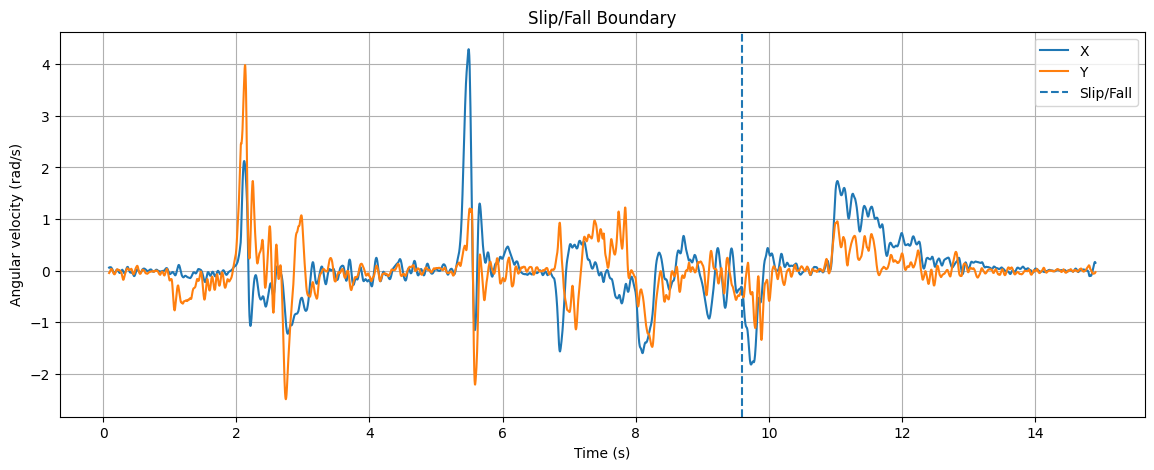

✓ Both classes are present.


In [ ]:
# CELL 12 — LABELING CHECK
print("Available window centers:",
      f"{features_df['center_time'].min():.2f}–{features_df['center_time'].max():.2f} s")
print("SLIP_TIME:", SLIP_TIME)

plt.figure(figsize=(14,5))
plt.plot(data["time"], data["x"], label="X")
plt.plot(data["time"], data["y"], label="Y")
plt.axvline(SLIP_TIME, linestyle="--", label="Slip/Fall")
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.title("Slip/Fall Boundary")
plt.legend()
plt.grid(True)
plt.show()

if safe_count == 0 or fall_count == 0:
    raise ValueError(
        "Both SAFE and FALL classes are required. "
        "Change SLIP_TIME to the actual physical slip/fall time, "
        "then rerun Cells 10 onward."
    )

print("✓ Both classes are present.")

In [ ]:
# CELL 13 — ML INPUT
X = features_df[FEATURES].to_numpy(dtype=np.float32)
y = features_df["label"].to_numpy(dtype=np.int32)

print("X:", X.shape)
print("y:", y.shape)

X: (28, 6)
y: (28,)


In [ ]:
# CELL 14 — TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train:", len(y_train))
print("Test :", len(y_test))
print("\nTrain classes:")
print(pd.Series(y_train).map({0:"SAFE",1:"FALL"}).value_counts())
print("\nTest classes:")
print(pd.Series(y_test).map({0:"SAFE",1:"FALL"}).value_counts())

if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
    raise ValueError("Train/test must both contain SAFE and FALL. Collect more labeled windows/trials.")

Train: 19
Test : 9

Train classes:
SAFE    13
FALL     6
Name: count, dtype: int64

Test classes:
SAFE    6
FALL    3
Name: count, dtype: int64


In [ ]:
# CELL 15 — STANDARDIZE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print(X_train_scaled.shape, X_test_scaled.shape)

(19, 6) (9, 6)


In [ ]:
# CELL 16 — BINARY MLP
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# CELL 17 — TRAIN
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.2667 - loss: 0.8908 - val_accuracy: 0.2500 - val_loss: 0.9133
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3333 - loss: 0.8679 - val_accuracy: 0.2500 - val_loss: 0.9165
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3333 - loss: 0.8483 - val_accuracy: 0.2500 - val_loss: 0.9192
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3333 - loss: 0.8285 - val_accuracy: 0.2500 - val_loss: 0.9221
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3333 - loss: 0.8110 - val_accuracy: 0.2500 - val_loss: 0.9238
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4000 - loss: 0.7910 - val_accuracy: 0.2500 - val_loss: 0.9256
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4000 - loss: 0.7715 - val_accuracy: 0.2500 - val_loss: 0.9278
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4000 - loss: 0.7568 - val_accuracy: 0.2500 - val_loss: 0.9293
Ep

In [ ]:
# CELL 18 — KERAS INFERENCE
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

probabilities = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (probabilities >= 0.5).astype(np.int32)

print(f"Keras test accuracy: {test_accuracy*100:.2f}%")
print("Actual samples:", len(y_test))
print("Predictions:", len(y_pred))

Keras test accuracy: 77.78%
Actual samples: 9
Predictions: 9


Accuracy : 0.7777777777777778
Precision: 0.6666666666666666
Recall   : 0.6666666666666666
F1       : 0.6666666666666666

Classification report:
              precision    recall  f1-score   support

        SAFE       0.83      0.83      0.83         6
        FALL       0.67      0.67      0.67         3

    accuracy                           0.78         9
   macro avg       0.75      0.75      0.75         9
weighted avg       0.78      0.78      0.78         9

Confusion Matrix:
[[5 1]
 [1 2]]


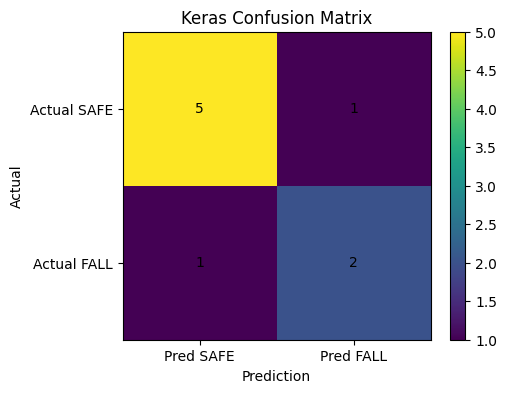

In [ ]:
# CELL 19 — KERAS VERIFICATION
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1       :", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification report:")
print(classification_report(
    y_test, y_pred,
    labels=[0,1],
    target_names=["SAFE","FALL"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.xticks([0,1], ["Pred SAFE","Pred FALL"])
plt.yticks([0,1], ["Actual SAFE","Actual FALL"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Keras Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
# CELL 20 — KERAS → FP32 TFLITE
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_fp32 = converter.convert()

with open("payload_stability_model.tflite", "wb") as f:
    f.write(tflite_fp32)

fp32_size_kb = len(tflite_fp32) / 1024
print(f"FP32 TFLite size: {fp32_size_kb:.2f} KB")

Saved artifact at '/tmp/tmpg1mj88ha'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140095653053072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653053648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653060560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653062096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653062672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653065936: TensorSpec(shape=(), dtype=tf.resource, name=None)
FP32 TFLite size: 3.02 KB


In [ ]:
# CELL 21 — REPRESENTATIVE DATASET
def representative_dataset():
    for i in range(min(100, len(X_train_scaled))):
        yield [X_train_scaled[i:i+1].astype(np.float32)]

print("Representative dataset ready.")

Representative dataset ready.


In [ ]:
# ============================================================
# CONVERT FP32 KERAS MODEL TO FULL INT8 TFLITE
# ============================================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable full integer quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Representative dataset
def representative_dataset():
    for i in range(min(100, len(X_train_scaled))):
        sample = X_train_scaled[i:i+1].astype(np.float32)
        yield [sample]

converter.representative_dataset = representative_dataset

# Force integer operations
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

# IMPORTANT: use tf.int8, NOT np.int8
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert
tflite_int8 = converter.convert()

# Save
with open("payload_stability_model_int8.tflite", "wb") as f:
    f.write(tflite_int8)

print("INT8 TFLite model created successfully!")
print("Model size:",
      round(len(tflite_int8) / 1024, 2), "KB")

Saved artifact at '/tmp/tmpsw8u6zzb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140095653053072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653053648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653060560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653062096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653062672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140095653065936: TensorSpec(shape=(), dtype=tf.resource, name=None)
INT8 TFLite model created successfully!
Model size: 3.2 KB


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
# ============================================================
# LOAD INT8 TFLITE MODEL
# ============================================================

interpreter = tf.lite.Interpreter(
    model_path="payload_stability_model_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:")
print(input_details)

print("\nOutput details:")
print(output_details)

Input details:
[{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.01713523641228676, -33), 'quantization_parameters': {'scales': array([0.01713524], dtype=float32), 'zero_points': array([-33], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Output details:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 10, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# ============================================================
# CHECK QUANTIZATION PARAMETERS
# ============================================================

input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

print("Input scale:", input_scale)
print("Input zero point:", input_zero_point)

print("\nOutput scale:", output_scale)
print("Output zero point:", output_zero_point)

Input scale: 0.01713523641228676
Input zero point: -33

Output scale: 0.00390625
Output zero point: -128


In [ ]:
# ============================================================
# INT8 TFLITE INFERENCE
# ============================================================

def tflite_predict(sample):

    # Make sure sample has shape (1, 6)
    sample = np.asarray(sample, dtype=np.float32).reshape(1, 6)

    # Quantize float input to INT8
    quantized_input = np.round(
        sample / input_scale + input_zero_point
    ).astype(np.int8)

    # Set input
    interpreter.set_tensor(
        input_details[0]["index"],
        quantized_input
    )

    # Run inference
    interpreter.invoke()

    # Get INT8 output
    quantized_output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # Convert INT8 output back to float
    probability = (
        (quantized_output.astype(np.float32) - output_zero_point)
        * output_scale
    )

    return float(probability[0][0])

In [ ]:
# ============================================================
# TEST ONE SAMPLE
# ============================================================

sample = X_test_scaled[0]

probability = tflite_predict(sample)

prediction = 1 if probability >= 0.5 else 0

label = "FALL" if prediction == 1 else "SAFE"

print("P(FALL):", probability)
print("Prediction:", label)

P(FALL): 0.30859375
Prediction: SAFE


In [ ]:
# ============================================================
# TFLITE PREDICTIONS FOR ENTIRE TEST SET
# ============================================================

y_pred_tflite_prob = []

for sample in X_test_scaled:
    prob = tflite_predict(sample)
    y_pred_tflite_prob.append(prob)

y_pred_tflite_prob = np.array(y_pred_tflite_prob)

# Convert probabilities to classes
y_pred_tflite = (
    y_pred_tflite_prob >= 0.5
).astype(int)

print("Number of test samples:", len(X_test_scaled))
print("Number of predictions:", len(y_pred_tflite))

Number of test samples: 9
Number of predictions: 9


In [ ]:
# ============================================================
# DISPLAY TFLITE PREDICTIONS
# ============================================================

for i in range(len(y_pred_tflite)):

    actual = "FALL" if y_test[i] == 1 else "SAFE"
    predicted = "FALL" if y_pred_tflite[i] == 1 else "SAFE"

    print(
        f"Sample {i+1}: "
        f"P(FALL)={y_pred_tflite_prob[i]:.4f} | "
        f"Actual={actual} | "
        f"Predicted={predicted}"
    )

Sample 1: P(FALL)=0.3086 | Actual=SAFE | Predicted=SAFE
Sample 2: P(FALL)=0.6367 | Actual=FALL | Predicted=FALL
Sample 3: P(FALL)=0.3086 | Actual=FALL | Predicted=SAFE
Sample 4: P(FALL)=0.3242 | Actual=SAFE | Predicted=SAFE
Sample 5: P(FALL)=0.4102 | Actual=SAFE | Predicted=SAFE
Sample 6: P(FALL)=0.3047 | Actual=SAFE | Predicted=SAFE
Sample 7: P(FALL)=0.5547 | Actual=FALL | Predicted=FALL
Sample 8: P(FALL)=0.6055 | Actual=SAFE | Predicted=FALL
Sample 9: P(FALL)=0.7148 | Actual=SAFE | Predicted=FALL


In [ ]:
# ============================================================
# VERIFY TFLITE PREDICTIONS
# ============================================================

y_test_array = np.asarray(y_test).astype(int)

print("Actual labels shape:    ", y_test_array.shape)
print("TFLite predictions shape:", y_pred_tflite.shape)

if len(y_test_array) != len(y_pred_tflite):
    raise ValueError(
        f"Length mismatch: y_test={len(y_test_array)}, "
        f"predictions={len(y_pred_tflite)}"
    )

print("\nTFLite inference completed successfully!")

print("\nActual label distribution:")
print(pd.Series(y_test_array).value_counts().sort_index())

print("\nPredicted label distribution:")
print(pd.Series(y_pred_tflite).value_counts().sort_index())

Actual labels shape:     (9,)
TFLite predictions shape: (9,)

TFLite inference completed successfully!

Actual label distribution:
0    6
1    3
Name: count, dtype: int64

Predicted label distribution:
0    5
1    4
Name: count, dtype: int64


In [ ]:
# ============================================================
# TFLITE ACCURACY
# ============================================================

from sklearn.metrics import accuracy_score

tflite_accuracy = accuracy_score(
    y_test_array,
    y_pred_tflite
)

print(
    f"TFLite INT8 Accuracy: "
    f"{tflite_accuracy * 100:.2f}%"
)

TFLite INT8 Accuracy: 66.67%


Confusion Matrix:
[[4 2]
 [1 2]]


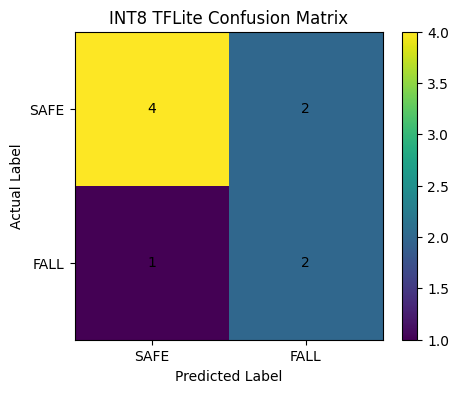

In [ ]:
# ============================================================
# TFLITE CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_tflite = confusion_matrix(
    y_test_array,
    y_pred_tflite,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm_tflite)

plt.figure(figsize=(5, 4))

plt.imshow(cm_tflite)

plt.title("INT8 TFLite Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["SAFE", "FALL"]
)

plt.yticks(
    [0, 1],
    ["SAFE", "FALL"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_tflite[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_array,
        y_pred_tflite,
        labels=[0, 1],
        target_names=["SAFE", "FALL"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        SAFE       0.80      0.67      0.73         6
        FALL       0.50      0.67      0.57         3

    accuracy                           0.67         9
   macro avg       0.65      0.67      0.65         9
weighted avg       0.70      0.67      0.68         9



In [ ]:
# ============================================================
# SINGLE WINDOW TFLITE INFERENCE
# ============================================================

# Select one test window
sample_index = 0

sample = X_test_scaled[sample_index]

probability = tflite_predict(sample)

if probability >= 0.5:
    prediction = "FALL"
else:
    prediction = "SAFE"

print("Input features:")
print(sample)

print("\nP(FALL):", round(probability, 4))

print("Prediction:", prediction)

Input features:
[-0.2381133  -0.86411047 -0.9641232  -0.11070917 -1.030161   -1.0608944 ]

P(FALL): 0.3086
Prediction: SAFE


In [ ]:
# ============================================================
# DISPLAY FEATURES OF ONE WINDOW
# ============================================================

feature_names = [
    "X Mean",
    "X Std",
    "X RMS",
    "Y Mean",
    "Y Std",
    "Y RMS"
]

print("Features used by the TinyML model:\n")

for name, value in zip(feature_names, sample):
    print(f"{name:10s}: {value:.6f}")

Features used by the TinyML model:

X Mean    : -0.238113
X Std     : -0.864110
X RMS     : -0.964123
Y Mean    : -0.110709
Y Std     : -1.030161
Y RMS     : -1.060894


In [ ]:
# ============================================================
# TFLITE MODEL SIZE
# ============================================================

import os

model_size_bytes = os.path.getsize(
    "payload_stability_model_int8.tflite"
)

model_size_kb = model_size_bytes / 1024

print("TFLite model size:")
print(f"{model_size_bytes} bytes")
print(f"{model_size_kb:.2f} KB")

TFLite model size:
3280 bytes
3.20 KB


In [ ]:
# ============================================================
# CONVERT TFLITE MODEL TO C HEADER FILE
# ============================================================

tflite_file = "payload_stability_model_int8.tflite"
header_file = "payload_stability_model_int8.h"

with open(tflite_file, "rb") as f:
    model_data = f.read()

with open(header_file, "w") as f:

    f.write("#ifndef PAYLOAD_STABILITY_MODEL_INT8_H\n")
    f.write("#define PAYLOAD_STABILITY_MODEL_INT8_H\n\n")

    f.write("#include <stdint.h>\n\n")

    f.write("const unsigned char payload_stability_model_int8[] = {\n")

    for i, byte in enumerate(model_data):

        if i % 12 == 0:
            f.write("  ")

        f.write(f"0x{byte:02x}")

        if i != len(model_data) - 1:
            f.write(", ")

        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write("\n};\n\n")

    f.write(
        "const unsigned int "
        "payload_stability_model_int8_len = "
        f"{len(model_data)};\n\n"
    )

    f.write("#endif\n")

print("C header file created successfully!")
print("File:", header_file)
print("Model bytes:", len(model_data))

C header file created successfully!
File: payload_stability_model_int8.h
Model bytes: 3280


In [ ]:
# ============================================================
# SAVE FEATURE INFORMATION AND SCALER
# ============================================================

import pickle

feature_info = {
    "features": feature_names,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist()
}

with open(
    "payload_stability_preprocessing.pkl",
    "wb"
) as f:

    pickle.dump(
        feature_info,
        f
    )

print("Preprocessing information saved.")
print("\nFeatures:")
print(feature_info["features"])

print("\nScaler mean:")
print(feature_info["scaler_mean"])

print("\nScaler scale:")
print(feature_info["scaler_scale"])

Preprocessing information saved.

Features:
['X Mean', 'X Std', 'X RMS', 'Y Mean', 'Y Std', 'Y RMS']

Scaler mean:
[0.02253037911692732, 0.3926172958392846, 0.4739214182880364, -0.03752363834677166, 0.3661839932595429, 0.409440423509008]

Scaler scale:
[0.3128570884106684, 0.28921572233257115, 0.33403553917620854, 0.20430448175735086, 0.2543459500324753, 0.2725609380014868]


In [ ]:
# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

print("=" * 60)
print("PAYLOAD STABILITY TinyML - FINAL RESULTS")
print("=" * 60)

print("\n1. Input Features:")
print("   X Mean, X Std, X RMS")
print("   Y Mean, Y Std, Y RMS")

print("\n2. Model:")
print("   Dense(16, ReLU)")
print("   Dense(8, ReLU)")
print("   Dense(1, Sigmoid)")

print("\n3. Classification:")
print("   0 = SAFE")
print("   1 = FALL")

print("\n4. TFLite INT8 Accuracy:")
print(f"   {tflite_accuracy * 100:.2f}%")

print("\n5. TFLite Model Size:")
print(f"   {model_size_kb:.2f} KB")

print("\n6. Confusion Matrix:")
print(cm_tflite)

print("\n7. Files Created:")
print("   payload_stability_model_int8.tflite")
print("   payload_stability_model_int8.h")
print("   payload_stability_preprocessing.pkl")

print("=" * 60)

PAYLOAD STABILITY TinyML - FINAL RESULTS

1. Input Features:
   X Mean, X Std, X RMS
   Y Mean, Y Std, Y RMS

2. Model:
   Dense(16, ReLU)
   Dense(8, ReLU)
   Dense(1, Sigmoid)

3. Classification:
   0 = SAFE
   1 = FALL

4. TFLite INT8 Accuracy:
   66.67%

5. TFLite Model Size:
   3.20 KB

6. Confusion Matrix:
[[4 2]
 [1 2]]

7. Files Created:
   payload_stability_model_int8.tflite
   payload_stability_model_int8.h
   payload_stability_preprocessing.pkl
